In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

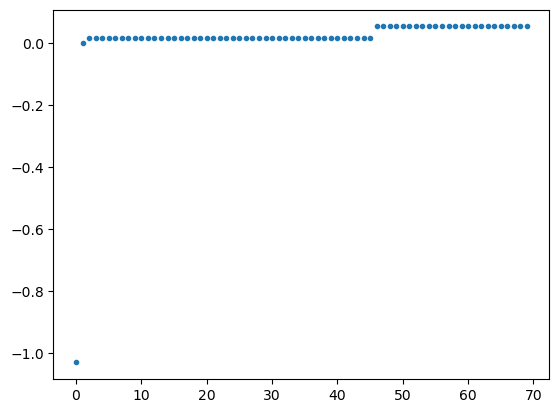

In [234]:
n_a = 25
n_b = 45
n = n_a + n_b

A = np.zeros((n_a + n_b,n_a+n_b))
B = np.zeros((n_a + n_b,n_a+n_b))
C = np.zeros((n_a + n_b,n_a+n_b))

A[:n_a, :n_a]= ((n_a + 1)/(n_a-1)) * (np.eye(n_a) - 1/n_a * np.ones((n_a,n_a)))
B[n_a:, n_a:]= (n_b + 1)/(n_b - 1) * (np.eye(n_b) - 1/n_b * np.ones((n_b,n_b)))
C[:, :]= (n + 1)/(n-1) * (np.eye(n) - 1/n * np.ones((n,n)))
Q = A + B - C

u, V = np.linalg.eigh(Q)
plt.plot(u, '.')

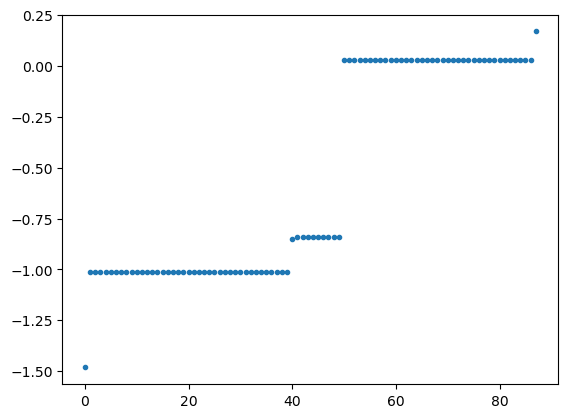

In [152]:
n_a_split = 10
n_b_split = n_a - n_a_split
n_split = n_a_split + n_b_split

A_split_tot = np.zeros((n_a + n_b,n_a+n_b))
A_split = np.zeros((n_a_split + n_b_split,n_a_split+n_b_split))
B_split = np.zeros((n_a_split + n_b_split,n_a_split+n_b_split))
C_split = np.zeros((n_a_split + n_b_split,n_a_split+n_b_split))

A_split[:n_a_split, :n_a_split]= ((n_a_split + 1)/(n_a_split-1)) * (np.eye(n_a_split) - 1/n_a * np.ones((n_a_split,n_a_split)))
B_split[n_a_split:, n_a_split:]= (n_b_split + 1)/(n_b_split - 1) * (np.eye(n_b_split) - 1/n_b * np.ones((n_b_split,n_b_split)))
C_split[:, :]= (n_split + 1)/(n_split-1) * (np.eye(n_split) - 1/n_split * np.ones((n_split,n_split)))

Q_split = A_split + B_split - C_split
A_split_tot[:n_a, :n_a] = Q_split

Q_split_tot = A_split_tot + B - C
u, V = np.linalg.eigh(Q_split_tot)
plt.plot(u, '.')

<Axes: >

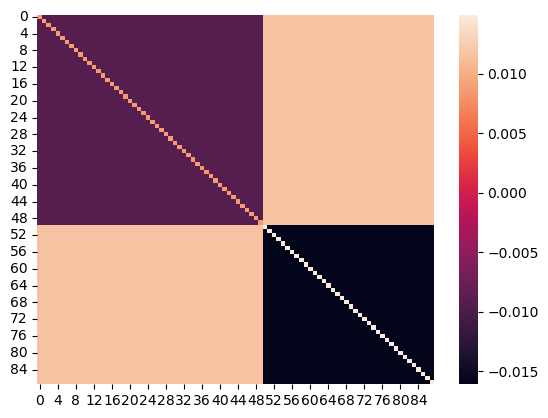

In [153]:
sb.heatmap(Q)

<Axes: >

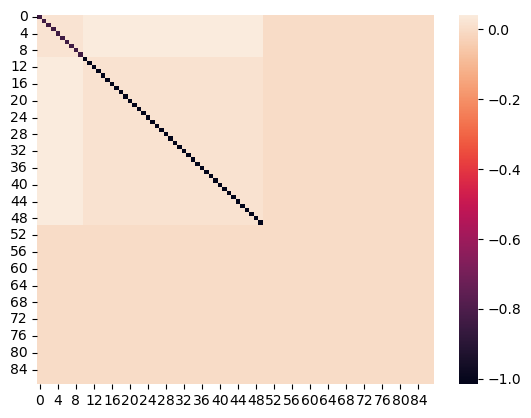

In [154]:
delta = Q_split_tot - Q
sb.heatmap(delta)

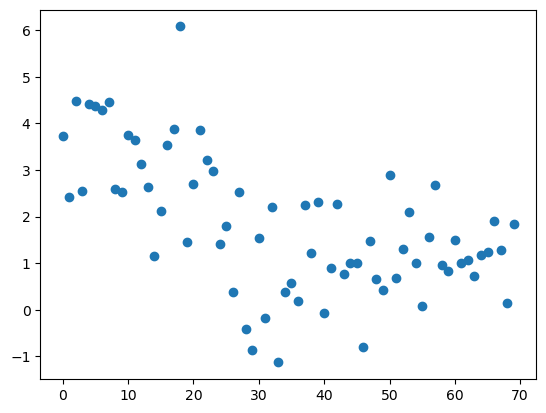

In [245]:
sample_size = 100000
mu = np.zeros((n,1))
mu_a = 3
mu_b = 1
c = 0.5*mu_a + 0.5*mu_b 
mu[:n_a, :] = mu_a
mu[n_a:, :] = mu_b

# H_0 assumption samples
z0_samples = []
#for i in range(sample_size):
#    z_ = (2*n_b)/(n_a-1)*np.random.chisquare(n_a-1)  + (2*n_a)/(n_b-1)*np.random.chisquare(n_b - 1) - (n+1)*np.random.chisquare(1)
#    z_ *= sig**2/(n-1)#
#
#    z0_samples.append(z_)

# Outcome samples
z_samples = []
for i in range(sample_size):
    Y = np.random.normal(0,sig, (n,1))
    Z0_outcome = ((Y+c).T@(Q@ (Y+c) ))[0][0]
    z0_samples.append(Z0_outcome)
    
    Y = Y + mu
    Z_outcome = (Y.T@(Q@Y))[0][0]
    z_samples.append(Z_outcome)

_= plt.scatter(list(range(n)), Y)

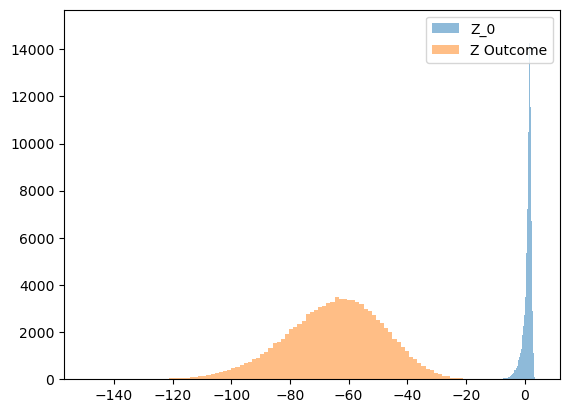

In [246]:
bins = 100
plt.hist(z0_samples, bins, alpha=0.5, label='Z_0')
plt.hist(z_samples, bins, alpha=0.5, label='Z Outcome')
plt.legend(loc='upper right')
plt.show()

In [247]:
# Numerical Quantile Function
ordered_samples = np.sort(z0_samples)

quantiles= [
    0.1, # 10%
    0.05, #5%
    0.01, #1%
    0.001, # 0.1%
    0.0001, # 0.01%
]
for q in quantiles:
    qnt = ordered_samples[int(len(ordered_samples)*q)]
    print(f"{q*100}% quantile: {qnt}")

    pct = sum(np.array(z_samples) < qnt)/sample_size
    print(f"From outcome simulation above we would reject {100*pct :.2f}% of the outcomes \n")

10.0% quantile: -0.8367537864225458
From outcome simulation above we would reject 100.00% of the outcomes 

5.0% quantile: -1.9982531146440616
From outcome simulation above we would reject 100.00% of the outcomes 

1.0% quantile: -4.820341920770098
From outcome simulation above we would reject 100.00% of the outcomes 

0.1% quantile: -9.064660916226286
From outcome simulation above we would reject 100.00% of the outcomes 

0.01% quantile: -12.964866513741796
From outcome simulation above we would reject 100.00% of the outcomes 

